In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, Binarizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
df = pd.read_csv("Cleaned/finaldataset.csv")
df.head()

,date,ConsumerPriceIndexAllItems,FEDRates,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
0,1954-07-01,0.0,0.80,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,5.8
1,1954-08-01,0.0,1.22,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.0
2,1954-09-01,0.0,1.07,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.1
3,1954-10-01,0.0,0.85,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.7
4,1954-11-01,0.0,0.83,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.3


In [3]:
if 'date' in df.columns:
    df = df.drop(columns=['date'])

In [4]:
X = df.drop(columns=['FEDRates'])
y = df['FEDRates']

In [5]:
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
X_binned = discretizer.fit_transform(X)

C:\Users\Sangram More\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [27]:
X_binned = pd.DataFrame(X_binned, columns=X.columns)
# X_binned.to_csv('NBTrain.csv', index=False)
X_binned.head()

,ConsumerPriceIndexAllItems,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
0,1.0,0.0,1.0,3.0,0.0,0.0,0.0,2.0
1,1.0,0.0,1.0,3.0,0.0,0.0,0.0,3.0
2,1.0,0.0,1.0,3.0,0.0,0.0,0.0,3.0
3,1.0,0.0,1.0,3.0,0.0,0.0,0.0,2.0
4,1.0,0.0,1.0,3.0,0.0,0.0,0.0,2.0


In [25]:
target_discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
y_binned = target_discretizer.fit_transform(y.values.reshape(-1, 1)).flatten()
y_binned[40:90]

array([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_binned, y_binned, test_size=0.2, random_state=42)

In [9]:
print("X_train shape:", X_train.shape)
print("y_train class distribution:", pd.Series(y_train).value_counts())

X_train shape: (676, 8)
y_train class distribution: 1.0    228
2.0    225
0.0    223
Name: count, dtype: int64


## 1. Multinomial Naive Bayes

In [11]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
mnb_preds = mnb.predict(X_test)
print("MultinomialNB Accuracy:", accuracy_score(y_test, mnb_preds))
print(classification_report(y_test, mnb_preds))

MultinomialNB Accuracy: 0.5352941176470588
              precision    recall  f1-score   support

         0.0       0.62      0.71      0.66        59
         1.0       0.33      0.09      0.14        54
         2.0       0.51      0.77      0.61        57

    accuracy                           0.54       170
   macro avg       0.49      0.53      0.47       170
weighted avg       0.49      0.54      0.48       170



## 2. Bernoulli Naive Bayes

In [12]:
binarizer = Binarizer()
X_bin_train = binarizer.fit_transform(X_train)
X_bin_test = binarizer.transform(X_test)

bnb = BernoulliNB()
bnb.fit(X_bin_train, y_train)
bnb_preds = bnb.predict(X_bin_test)
print("\nBernoulliNB Accuracy:", accuracy_score(y_test, bnb_preds))
print(classification_report(y_test, bnb_preds))


BernoulliNB Accuracy: 0.5823529411764706
              precision    recall  f1-score   support

         0.0       0.68      0.47      0.56        59
         1.0       0.55      0.33      0.41        54
         2.0       0.55      0.93      0.69        57

    accuracy                           0.58       170
   macro avg       0.59      0.58      0.56       170
weighted avg       0.60      0.58      0.56       170



## 3. Categorical Naive Bayes

In [13]:
cnb = CategoricalNB()
cnb.fit(X_train, y_train)
cnb_preds = cnb.predict(X_test)
print("\nCategoricalNB Accuracy:", accuracy_score(y_test, cnb_preds))
print(classification_report(y_test, cnb_preds))


CategoricalNB Accuracy: 0.7
              precision    recall  f1-score   support

         0.0       0.72      0.75      0.73        59
         1.0       0.59      0.44      0.51        54
         2.0       0.75      0.89      0.82        57

    accuracy                           0.70       170
   macro avg       0.69      0.69      0.68       170
weighted avg       0.69      0.70      0.69       170



## Results

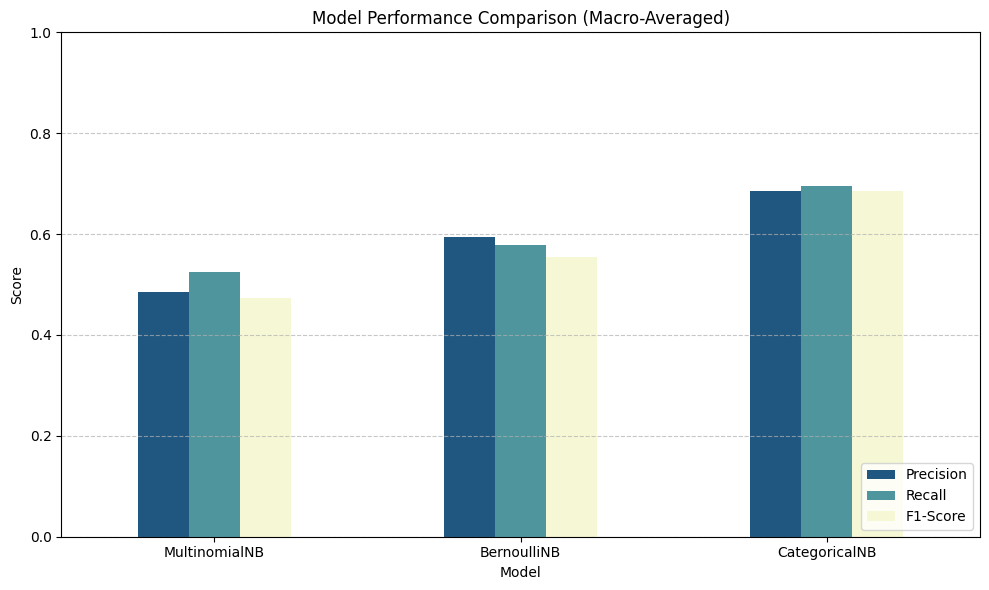

In [18]:
metrics_data = {
    "Model": ["MultinomialNB", "BernoulliNB", "CategoricalNB"],
    "Precision": [
        precision_score(y_test, mnb_preds, average='macro'),
        precision_score(y_test, bnb_preds, average='macro'),
        precision_score(y_test, cnb_preds, average='macro')
    ],
    "Recall": [
        recall_score(y_test, mnb_preds, average='macro'),
        recall_score(y_test, bnb_preds, average='macro'),
        recall_score(y_test, cnb_preds, average='macro')
    ],
    "F1-Score": [
        f1_score(y_test, mnb_preds, average='macro'),
        f1_score(y_test, bnb_preds, average='macro'),
        f1_score(y_test, cnb_preds, average='macro')
    ]
}

# Create DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Plot the metrics
metrics_df.set_index("Model").plot(kind="bar", figsize=(10, 6), color=["#205781", "#4F959D", "#F6F8D5"])
plt.title("Model Performance Comparison (Macro-Averaged)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

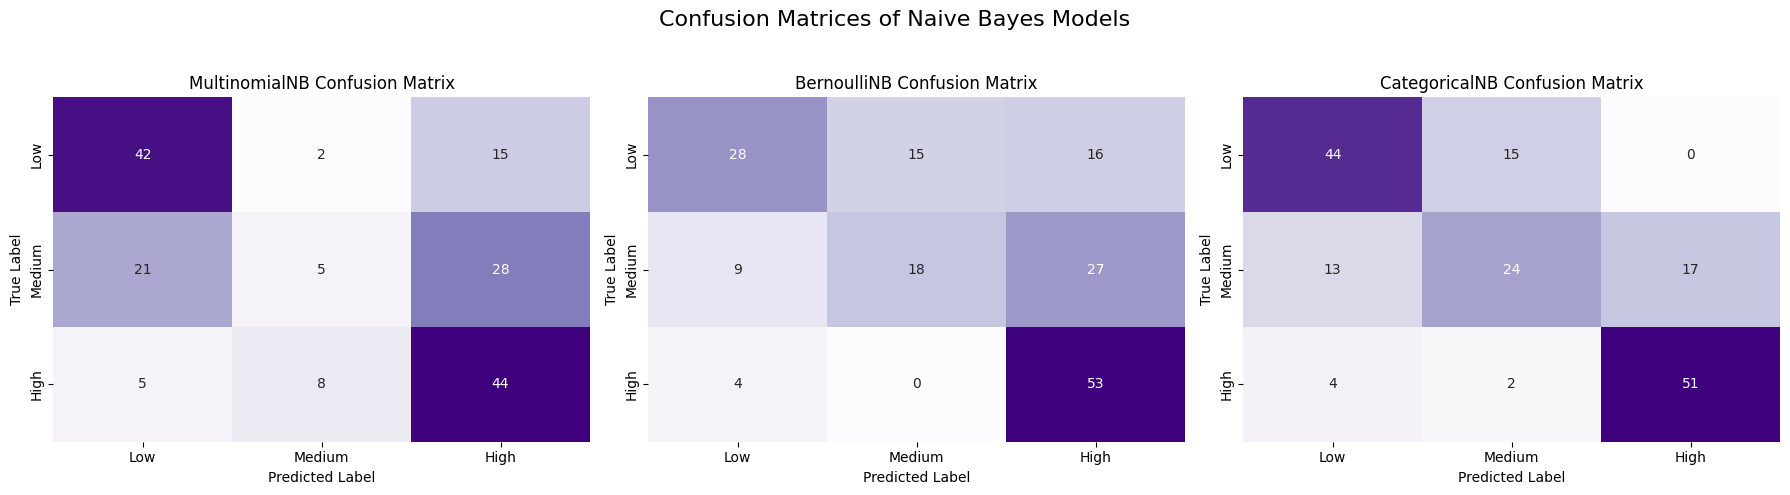

In [21]:
class_labels = ['Low', 'Medium', 'High']

# Compute confusion matrices
conf_mnb = confusion_matrix(y_test, mnb_preds)
conf_bnb = confusion_matrix(y_test, bnb_preds)
conf_cnb = confusion_matrix(y_test, cnb_preds)

# Plot side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    "MultinomialNB": conf_mnb,
    "BernoulliNB": conf_bnb,
    "CategoricalNB": conf_cnb
}

for ax, (name, matrix) in zip(axes, models.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Purples", cbar=False,
                xticklabels=class_labels, yticklabels=class_labels, ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Confusion Matrices of Naive Bayes Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()